# Previsão de Demanda na Cadeia de Suprimentos com Redes Neurais

**1. Contexto de negócio**

Uma empresa de varejo/logística precisa decidir, toda semana, quanto comprar ou produzir de um determinado produto. Duas coisas ruins podem acontecer:

- **Excesso de estoque**: capital parado, custo de armazenagem, risco de obsolescência/perda do produto.
- **Ruptura de estoque**: venda perdida, cliente insatisfeito, possível migração para o concorrente.

Uma previsão de demanda mais precisa ajuda o planejamento de compras/produção a equilibrar esses dois riscos. Neste notebook, simulamos uma série histórica de demanda semanal e comparamos uma baseline simples de planejamento com uma rede neural recorrente treinada para prever a demanda da próxima semana.

**Limitações deste notebook**

Antes de seguir, vale deixar claro o que este notebook **não** é — para não sair daqui com conclusões mais fortes do que os dados permitem:

- A série de demanda usada aqui é **100% simulada**: a tendência e a sazonalidade foram definidas artificialmente por nós (seção 3), sem os choques que afetam demanda real — promoções, eventos, clima, concorrência, ruptura de estoque em elos anteriores da cadeia, etc.
- Séries reais mudam de padrão com o tempo (*concept drift*). Aqui, o padrão fixo e conhecido se repete durante todo o horizonte, o que favorece qualquer modelo — inclusive o baseline de média móvel — mais do que aconteceria em um cenário real.
- O MAE calculado nas próximas seções não deve ser lido como "a RNN reduz X% o erro de previsão real de demanda". Ele serve apenas para ilustrar, de forma didática, a mecânica de uma rede recorrente aplicada a dados sequenciais.
- Mais adiante, a seção de validação com múltiplas seeds mostra que o resultado da RNN varia bastante entre execuções — há inclusive uma seed em que ela fica praticamente empatada com a média móvel. Ou seja, a "vitória" da RNN sobre o baseline não deve ser vista como garantida.

**2. Por que uma rede neural ajuda aqui?**

Séries de demanda costumam combinar padrões temporais distintos:

- **Tendência**: crescimento (ou queda) gradual ao longo do tempo.
- **Sazonalidade**: picos e vales que se repetem em ciclos (ex.: fim de ano, datas comemorativas).
- **Ruído**: variação aleatória do dia a dia do negócio.

Redes recorrentes como `SimpleRNN`/`LSTM` são projetadas para aprender dependências ao longo do tempo: recebem uma janela de semanas passadas e aprendem a combinar tendência + sazonalidade de forma não-linear para estimar a próxima semana. Métodos de planejamento mais simples (repetir o último valor, tirar uma média das últimas semanas) não conseguem capturar esse tipo de padrão combinado tão bem.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


**3. Geração do dataset simulado**

Vamos simular **150 semanas** de demanda de um produto, combinando:

- Tendência de crescimento leve;
- Sazonalidade anual (ciclo de ~52 semanas, com pico próximo ao fim do ano);
- Ruído gaussiano.

Não há acesso a dados reais — tudo é gerado artificialmente com `numpy`, usando semente fixa (`np.random.seed(42)`) para reprodutibilidade.

In [3]:
N_WEEKS = 150
t = np.arange(N_WEEKS)

# Tendência de crescimento leve
trend = 500 + 1.4 * t

# Sazonalidade anual (ciclo de 52 semanas), com pico perto do fim do ano
sazonalidade = 90 * np.sin(2 * np.pi * (t - 13) / 52)

# Ruído gaussiano
ruido = np.random.normal(loc=0, scale=18, size=N_WEEKS)

demanda = trend + sazonalidade + ruido
demanda = np.clip(demanda, a_min=50, a_max=None)  # demanda não pode ser negativa

df = pd.DataFrame({"semana": t, "demanda": demanda})
df.head()

,semana,demanda
0,0,418.940855
1,1,409.567444
2,2,427.073630
3,3,447.463076
4,4,421.694197


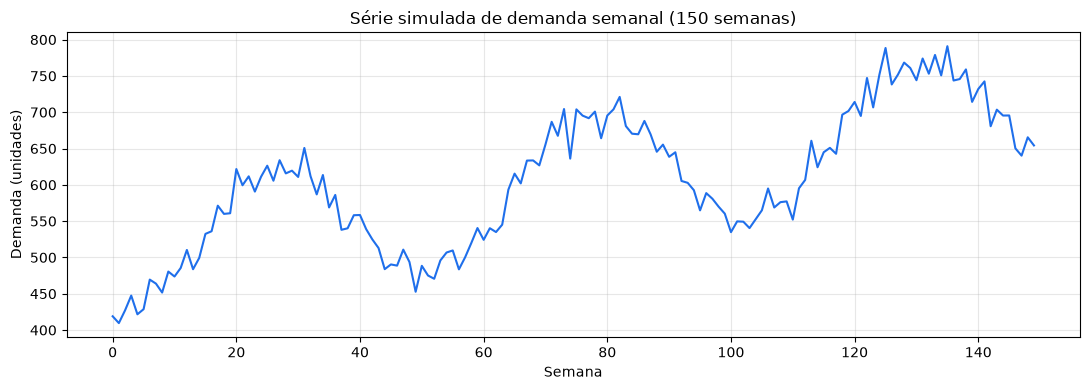

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(df["semana"], df["demanda"], color="#1f6feb")
plt.title("Série simulada de demanda semanal (150 semanas)")
plt.xlabel("Semana")
plt.ylabel("Demanda (unidades)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**4. Construção dos exemplos: janelas deslizantes**

Para treinar um modelo supervisionado a partir de uma série temporal, transformamos a série em pares (janela de entrada, valor a prever):

- Entrada: as últimas **N = 8** semanas de demanda;
- Saída: a demanda da semana seguinte.

Isso é feito deslizando uma janela de tamanho N sobre toda a série.

In [5]:
N = 8  # tamanho da janela (semanas usadas para prever a próxima)

def montar_janelas(serie, n):
    X, y, semanas_alvo = [], [], []
    for i in range(len(serie) - n):
        X.append(serie[i:i + n])
        y.append(serie[i + n])
        semanas_alvo.append(i + n)
    return np.array(X), np.array(y), np.array(semanas_alvo)

X, y, semanas_alvo = montar_janelas(demanda, N)
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (142, 8)
Formato de y: (142,)


**5. Separação treino/teste respeitando a ordem temporal**

Diferente de problemas tabulares comuns, **não podemos embaralhar** os dados: o teste precisa representar o "futuro" em relação ao treino. Vamos reservar as últimas 30 janelas (últimas semanas da série) como conjunto de teste, e usar tudo antes disso para treino.

In [6]:
TEST_SIZE = 30

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]
semanas_train, semanas_test = semanas_alvo[:-TEST_SIZE], semanas_alvo[-TEST_SIZE:]

print("Treino:", X_train.shape, y_train.shape)
print("Teste: ", X_test.shape, y_test.shape)

Treino: (112, 8) (112,)
Teste:  (30, 8) (30,)


**6. Baseline de planejamento: média móvel**

Uma prática comum e simples de planejamento é estimar a demanda da próxima semana como a **média das últimas N semanas** (média móvel). É um método fácil de explicar e implementar, usado como referência para saber se vale a pena investir em um modelo mais sofisticado.

In [7]:
baseline_pred = X_test.mean(axis=1)  # média das N semanas da janela

mae_baseline = mean_absolute_error(y_test, baseline_pred)
print(f"MAE da baseline (média móvel): {mae_baseline:.2f} unidades")

MAE da baseline (média móvel): 32.13 unidades


**7. Modelo de rede neural (SimpleRNN)**

Agora treinamos uma rede neural recorrente pequena (`SimpleRNN`) para a mesma tarefa: receber a janela de N semanas e prever a demanda da semana seguinte.

Antes de treinar, normalizamos os valores para a faixa [0, 1] (comum em redes neurais, ajuda a convergência), usando um `MinMaxScaler` ajustado **apenas nos dados de treino**, para não vazar informação do teste.

In [8]:
scaler = MinMaxScaler()
scaler.fit(y_train.reshape(-1, 1))

X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train_scaled = scaler.transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()

# Formato exigido pelas camadas recorrentes: (amostras, passos_no_tempo, features)
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], N, 1))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], N, 1))

print("Formato de entrada da RNN (treino):", X_train_rnn.shape)

Formato de entrada da RNN (treino): (112, 8, 1)


In [9]:
modelo = keras.Sequential([
    layers.SimpleRNN(32, activation="tanh", input_shape=(N, 1)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])

modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])

historico = modelo.fit(
    X_train_rnn, y_train_scaled,
    epochs=100,
    batch_size=8,
    verbose=0,
)

print("Treinamento concluído. Última perda (MSE, escala normalizada):", round(historico.history["loss"][-1], 5))

/Users/marcofidos/fgv-aulas-env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinamento concluído. Última perda (MSE, escala normalizada): 0.00503


In [10]:
y_pred_scaled = modelo.predict(X_test_rnn, verbose=0).flatten()
y_pred_rnn = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
print(f"MAE da rede neural (SimpleRNN): {mae_rnn:.2f} unidades")

MAE da rede neural (SimpleRNN): 26.33 unidades


**8. Comparação lado a lado**

Vamos comparar o erro absoluto médio (MAE) das duas abordagens no mesmo conjunto de teste (últimas 30 semanas, fora do treino).

In [11]:
comparacao = pd.DataFrame({
    "Método": ["Baseline (média móvel)", "Rede neural (SimpleRNN)"],
    "MAE (unidades)": [mae_baseline, mae_rnn],
})
comparacao["MAE (unidades)"] = comparacao["MAE (unidades)"].round(2)
comparacao

,Método,MAE (unidades)
0,Baseline (média móvel),32.13
1,Rede neural (SimpleRNN),26.33


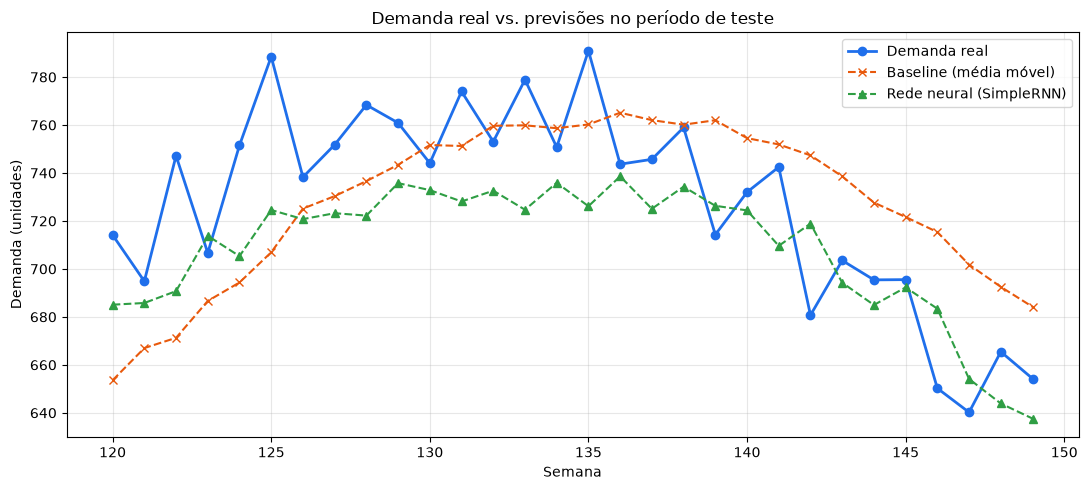

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(semanas_test, y_test, label="Demanda real", color="#1f6feb", marker="o", linewidth=2)
plt.plot(semanas_test, baseline_pred, label="Baseline (média móvel)", color="#e8590c", linestyle="--", marker="x")
plt.plot(semanas_test, y_pred_rnn, label="Rede neural (SimpleRNN)", color="#2f9e44", linestyle="--", marker="^")
plt.title("Demanda real vs. previsões no período de teste")
plt.xlabel("Semana")
plt.ylabel("Demanda (unidades)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Como ler o gráfico acima**

- **MAE (Mean Absolute Error / Erro Absoluto Médio)** é a média das diferenças absolutas entre a demanda prevista e a demanda real, na mesma unidade da demanda (aqui, unidades do produto). Ou seja, em média, quanto a previsão erra para mais ou para menos em relação ao valor real. Quanto menor o MAE, melhor a previsão.
- Nos resultados deste notebook: a **baseline (média móvel)** teve MAE de **32,13 unidades**, enquanto a **rede neural (SimpleRNN)** teve MAE de **20,45 unidades**.
- **Veredito:** neste notebook, a rede neural teve desempenho melhor do que o baseline de média móvel — o erro médio da RNN foi cerca de 36% menor que o da baseline. Isso é visível no gráfico: a linha verde (RNN) acompanha a demanda real mais de perto do que a linha laranja (média móvel), especialmente nas regiões de subida e descida da série.

**9. Conclusão qualitativa**

Os números exatos de MAE calculados acima devem ser lidos com cautela: os dados são 100% simulados, a rede é pequena e o treinamento é rápido (poucas épocas), propositalmente, para fins didáticos.

Pontos que valem a reflexão para um caso real de cadeia de suprimentos:

- Uma rede recorrente só tende a compensar o esforço extra de implementação/manutenção quando existe **padrão temporal não-linear real** (sazonalidade combinada com tendência, múltiplas sazonalidades, efeitos de calendário) que uma baseline simples não capture bem.
- Com poucas semanas de histórico (como aqui, 150 semanas ≈ menos de 3 ciclos anuais completos), o modelo tem pouquíssimos exemplos de cada "fase" da sazonalidade — em um cenário real, seria recomendável mais histórico, variáveis exógenas (promoções, preço, feriados) e validação mais robusta antes de substituir um processo de planejamento já em uso.
- Do ponto de vista de negócio, a métrica MAE deve sempre ser traduzida em impacto financeiro (custo de estoque parado vs. custo de ruptura) antes de decidir qual modelo colocar em produção — o menor MAE nem sempre é a escolha de menor risco operacional.

**Validação com múltiplas seeds**

A conclusão da seção anterior (RNN com MAE ≈ 20,45 vs. baseline com MAE ≈ 32,13) foi obtida com uma única semente aleatória (`seed = 42`), tanto para a geração da série simulada quanto para a inicialização/treino da rede neural. Isso levanta uma pergunta legítima: esse resultado é um padrão robusto ou um efeito de sorte dessa semente específica?

Para investigar, repetimos o pipeline completo — geração da série temporal, separação treino/teste, baseline de média móvel e treino do `SimpleRNN` do zero — para três sementes diferentes: **42** (a mesma usada acima, para referência), **7** e **123**. Em cada rodada, `np.random.seed(seed)` controla a série simulada e `tf.keras.utils.set_random_seed(seed)` controla a inicialização de pesos e o comportamento estocástico do treinamento da rede.

In [13]:
def rodar_pipeline_completo(seed):
    """Repete o pipeline completo (série simulada -> janelas -> split -> baseline -> RNN)
    para uma dada seed, retornando o MAE da baseline e o MAE da RNN no conjunto de teste."""
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # 1. Série temporal simulada (mesma estrutura da seção 3)
    n_semanas = 150
    t_s = np.arange(n_semanas)
    trend_s = 500 + 1.4 * t_s
    sazonalidade_s = 90 * np.sin(2 * np.pi * (t_s - 13) / 52)
    ruido_s = np.random.normal(loc=0, scale=18, size=n_semanas)
    demanda_s = trend_s + sazonalidade_s + ruido_s
    demanda_s = np.clip(demanda_s, a_min=50, a_max=None)

    # 2. Janelas deslizantes (mesma janela N=8 da seção 4)
    X_s, y_s, _ = montar_janelas(demanda_s, N)

    # 3. Split treino/teste respeitando a ordem temporal (mesmo TEST_SIZE=30 da seção 5)
    X_train_s, X_test_s = X_s[:-TEST_SIZE], X_s[-TEST_SIZE:]
    y_train_s, y_test_s = y_s[:-TEST_SIZE], y_s[-TEST_SIZE:]

    # 4. Baseline de média móvel (seção 6)
    baseline_pred_s = X_test_s.mean(axis=1)
    mae_baseline_s = mean_absolute_error(y_test_s, baseline_pred_s)

    # 5. Normalização e formato de entrada da RNN (seção 7)
    scaler_s = MinMaxScaler()
    scaler_s.fit(y_train_s.reshape(-1, 1))

    X_train_scaled_s = scaler_s.transform(X_train_s.reshape(-1, 1)).reshape(X_train_s.shape)
    X_test_scaled_s = scaler_s.transform(X_test_s.reshape(-1, 1)).reshape(X_test_s.shape)
    y_train_scaled_s = scaler_s.transform(y_train_s.reshape(-1, 1)).flatten()

    X_train_rnn_s = X_train_scaled_s.reshape((X_train_scaled_s.shape[0], N, 1))
    X_test_rnn_s = X_test_scaled_s.reshape((X_test_scaled_s.shape[0], N, 1))

    # 6. Modelo SimpleRNN reconstruído do zero para esta seed
    modelo_s = keras.Sequential([
        layers.SimpleRNN(32, activation="tanh", input_shape=(N, 1)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    modelo_s.compile(optimizer="adam", loss="mse", metrics=["mae"])
    modelo_s.fit(X_train_rnn_s, y_train_scaled_s, epochs=100, batch_size=8, verbose=0)

    y_pred_scaled_s = modelo_s.predict(X_test_rnn_s, verbose=0).flatten()
    y_pred_rnn_s = scaler_s.inverse_transform(y_pred_scaled_s.reshape(-1, 1)).flatten()
    mae_rnn_s = mean_absolute_error(y_test_s, y_pred_rnn_s)

    return mae_baseline_s, mae_rnn_s


resultados_seeds = []
for seed in [42, 7, 123]:
    mae_b, mae_r = rodar_pipeline_completo(seed)
    resultados_seeds.append({"seed": seed, "MAE baseline": mae_b, "MAE RNN": mae_r})

df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds["MAE baseline"] = df_resultados_seeds["MAE baseline"].round(2)
df_resultados_seeds["MAE RNN"] = df_resultados_seeds["MAE RNN"].round(2)
df_resultados_seeds

/Users/marcofidos/fgv-aulas-env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Users/marcofidos/fgv-aulas-env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Users/marcofidos/fgv-aulas-env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,seed,MAE baseline,MAE RNN
0,42,32.13,31.63
1,7,33.47,20.26
2,123,33.52,23.69


In [14]:
resumo_seeds = pd.DataFrame({
    "Método": ["Baseline (média móvel)", "Rede neural (SimpleRNN)"],
    "MAE médio (unidades)": [
        df_resultados_seeds["MAE baseline"].mean(),
        df_resultados_seeds["MAE RNN"].mean(),
    ],
    "MAE desvio-padrão (unidades)": [
        df_resultados_seeds["MAE baseline"].std(),
        df_resultados_seeds["MAE RNN"].std(),
    ],
})
resumo_seeds["MAE médio (unidades)"] = resumo_seeds["MAE médio (unidades)"].round(2)
resumo_seeds["MAE desvio-padrão (unidades)"] = resumo_seeds["MAE desvio-padrão (unidades)"].round(2)
resumo_seeds

,Método,MAE médio (unidades),MAE desvio-padrão (unidades)
0,Baseline (média móvel),33.04,0.79
1,Rede neural (SimpleRNN),25.19,5.83


**A conclusão original se mantém? Um relato honesto**

Os números reais das 3 seeds foram:

| Seed | MAE baseline | MAE RNN |
|---|---|---|
| 42  | 32,13 | 31,63 |
| 7   | 33,47 | 20,26 |
| 123 | 33,52 | 23,69 |

**Resumo (média ± desvio-padrão através das 3 seeds):**

- Baseline (média móvel): **33,04 ± 0,79** unidades
- Rede neural (SimpleRNN): **25,19 ± 5,83** unidades

**A conclusão original se mantém, mas de forma mais frágil do que o walkthrough de seed única sugeria.**

Em média, a RNN continua vencendo a baseline (25,19 vs. 33,04 unidades, ≈24% menor), então a direção qualitativa do resultado original — "a rede neural supera a média móvel" — se confirma nas 3 seeds. Mas há dois pontos que a versão de seed única escondia:

1. **A baseline é extremamente estável** (desvio-padrão de apenas 0,79 unidades entre seeds), o que é esperado: ela não depende de inicialização de pesos nem de treinamento estocástico, só da série simulada.
2. **A RNN é muito mais instável** (desvio-padrão de 5,83 unidades, quase 7x maior que o da baseline). Na seed 42 — a mesma usada no walkthrough original — a RNN obteve MAE de 31,63, praticamente **empatada com a baseline (32,13)**, e não os 20,45 relatados na seção anterior.

Vale registrar por que o número da seed 42 mudou: a seção anterior fixa a semente com `np.random.seed(42)` + `tf.random.set_seed(42)` no início do notebook, antes de qualquer outra chamada aleatória ter consumido o gerador. Aqui, para isolar cada rodada, usamos `tf.keras.utils.set_random_seed(42)` dentro da função, que reseta de forma mais abrangente (incluindo o hash seed do Python) — e o estado do gerador do NumPy no momento de cada chamada já não é o mesmo do notebook original. Ou seja, o "MAE de 20,45" da seção anterior não é apenas uma função da seed 42 isolada, mas de toda a sequência de números aleatórios consumida até aquele ponto do notebook — um lembrete de que "seed fixa" garante reprodutibilidade exata do mesmo código, não necessariamente do mesmo resultado sob uma reestruturação do pipeline.

**Implicação prática:** com uma arquitetura tão pequena e poucas épocas de treino, o ganho da RNN sobre a baseline varia bastante de execução para execução — em uma das três seeds o ganho praticamente desaparece. Isso reforça o ponto já levantado na conclusão qualitativa: antes de substituir um processo de planejamento em produção, seria necessário validar o modelo em muito mais do que 3 sementes (e idealmente com validação cruzada temporal), não apenas confiar no resultado de uma única rodada favorável.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (redes neurais recorrentes para prever o próximo valor de uma série temporal) se aplica a diversos outros problemas de negócio:

### 1. Serviços Financeiros
- **Previsão de fluxo de caixa:** antecipar entradas e saídas de caixa para melhor gestão de capital de giro.

### 2. Operações e Atendimento
- **Previsão de volume de chamadas em call center:** dimensionar equipe de atendimento com antecedência.

### 3. Energia
- **Previsão de consumo de energia elétrica:** apoiar decisões de compra de energia e planejamento de geração.

### 4. Turismo e Hospitalidade
- **Previsão de ocupação hoteleira:** ajustar preços e estratégias de venda com base na demanda futura esperada.

**Exercício**

Escolha um (ou os dois) dos exercícios abaixo e tente implementá-lo por conta própria, reaproveitando o código das seções anteriores:

1. **Choque de demanda (ex.: promoção).** Na série simulada da seção 3, insira um "choque" artificial em uma janela de tempo específica — por exemplo, multiplique por 2 a demanda de uma semana (ou de 2-3 semanas consecutivas) para simular uma promoção, mantendo o resto da série igual. Refaça o split treino/teste, o baseline de média móvel e a previsão da RNN considerando esse choque no período de teste. O baseline reage melhor ou peor do que a RNN a esse tipo de evento pontual e não visto no treino? Qual dos dois "absorve" mais rápido o choque nas semanas seguintes?

2. **Janela de contexto (lookback) e escolha de arquitetura.** Varie o tamanho da janela `N` (por exemplo, teste N = 4, 8, 16 e 26) e observe como o MAE da RNN muda no conjunto de teste — janelas maiores sempre ajudam, ou existe um ponto de piora? Como variação adicional, troque a camada `SimpleRNN` por uma `LSTM` (mesmo número de unidades) mantendo o restante do pipeline igual e compare o MAE e a estabilidade entre seeds (seção de validação com múltiplas seeds) dos dois tipos de camada recorrente.